In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

from simplexity.generative_processes.builder import build_hidden_markov_model
from simplexity.generative_processes.generator import generate_data_batch_with_full_history
from simplexity.utils.pytorch_utils import jax_to_torch
from src.hmm.hmm import belief_to_barycentric

from tqdm.auto import tqdm
import transformer_lens as tl

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Parameters

In [3]:
SEQ_LENGTH = 2000
HMM_CONCEPTS = ['A', 'B', 'C']
N_SEQUENCES = 10

In [4]:
hmm = build_hidden_markov_model(
    "leopard",
    process_params={"x": 0.5},
    device=None,
)

## Build HMM & Generate Sequences

In [5]:
hmm = build_hidden_markov_model(
    "mess3",
    process_params={"x": 0.05, "a": 0.85},
    device=None,
)

print(f"Vocab size (symbols): {hmm.vocab_size}")
print(f"Num hidden states: {hmm.num_states}")
print(f"Initial state (belief): {jax_to_torch(hmm.initial_state).tolist()}")

emission_rows = []
for i in range(hmm.num_states):
    pure_state = jnp.zeros(hmm.num_states).at[i].set(1.0)
    obs_probs = hmm.observation_probability_distribution(pure_state)
    emission_rows.append(jax_to_torch(obs_probs))
emission_matrix = torch.stack(emission_rows)

print(f"\nEmission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")

Vocab size (symbols): 3
Num hidden states: 3
Initial state (belief): [0.33333343267440796, 0.3333333134651184, 0.33333325386047363]

Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1137, 0.7725, 0.1137],
        [0.1138, 0.1138, 0.7725]])

Row sums (should be 1): tensor([1., 1., 1.])


In [6]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

gen_result = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

inputs_jax = gen_result["inputs"]
belief_states_jax = gen_result["belief_states"]
labels_jax = gen_result["labels"]
prefix_probs = gen_result["prefix_probabilities"]

tokens = jax_to_torch(inputs_jax)
tokens_y = jax_to_torch(labels_jax)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all = jax_to_torch(obs_probs_all_jax)

walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")

Num sequences: 10, Sequence length: 2000
First 20 tokens (seq 0): ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'C', 'C', 'C', 'A', 'B']
Belief states shape: (10, 2000, 3)
Belief states sum to 1? True


In [7]:
obs_probs_all[0][:10]

tensor([[0.1632, 0.1632, 0.6737],
        [0.1221, 0.1221, 0.7558],
        [0.1177, 0.1177, 0.7646],
        [0.1173, 0.1173, 0.7654],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1367, 0.3742, 0.4891],
        [0.1243, 0.6914, 0.1843]])

### OBS prob not belief state

In [8]:
belief_to_barycentric(obs_probs_all.reshape(-1,3).cpu(), obs_probs_all.reshape(-1,3).cpu())

In [9]:
belief_to_barycentric(belief_states_all.reshape(-1,3), belief_states_all.reshape(-1,3))

## Load Model (TransformerLens)

In [10]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
N_DEVICES = min(torch.cuda.device_count(), 4)

print(f"Loading {MODEL_NAME} across {N_DEVICES} GPUs...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device="cuda",
    n_devices=N_DEVICES,
    torch_dtype=torch.float16,
    n_ctx=4098
)
model.eval()
print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Context window: {model.cfg.n_ctx}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.2-3B across 4 GPUs...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.24it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 4098


In [11]:
def get_concept_token_ids(model, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids = model.to_tokens(spaced, prepend_bos=False)[0]
        concept_to_id[concept] = ids[-1].item()
    return concept_to_id

In [12]:
belief_states_all[0]

array([[0.07500003, 0.07500001, 0.84999996],
       [0.01266352, 0.01266351, 0.974673  ],
       [0.00602964, 0.00602964, 0.98794067],
       ...,
       [0.98921233, 0.00542329, 0.00536437],
       [0.98930264, 0.00535115, 0.00534624],
       [0.9893109 , 0.00534472, 0.00534431]],
      shape=(2000, 3), dtype=float32)

## Forward Pass (with activation caching)

In [13]:
LAYERS_TO_ANALYZE = list(range(model.cfg.n_layers))
print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")

letter_set = set(HMM_CONCEPTS)

all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}
all_logits = []
all_beliefs = []
all_positions = []

for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
    seq_concepts = walk_concepts[seq_idx]
    beliefs = belief_states_all[seq_idx]

    prompt = seq_concepts[0] + " " + " ".join(seq_concepts[1:])
    input_ids = model.to_tokens(prompt, prepend_bos=True).to(model.embed.W_E.device)
    str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

    positions = [i for i, tok in enumerate(str_tokens) if tok.strip() in letter_set]

    n_use = min(len(positions), len(seq_concepts))
    if len(positions) != len(seq_concepts):
        print(f"Warning seq {seq_idx}: expected {len(seq_concepts)} letter positions, got {len(positions)}")
    positions = positions[:n_use]

    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_ids,
            names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE],
            return_type=None,
        )

        for layer in LAYERS_TO_ANALYZE:
            hook_name = f"blocks.{layer}.hook_resid_post"
            layer_acts = cache[hook_name][0]
            letter_acts = layer_acts[positions].cpu().float().numpy()
            all_activations[layer].append(letter_acts)

        last_resid = cache[f"blocks.{LAYERS_TO_ANALYZE[-1]}.hook_resid_post"]
        last_resid = last_resid.to(model.unembed.W_U.device)
        logits = model.unembed(model.ln_final(last_resid))
        seq_logits = logits[0, positions].cpu().float().detach().numpy()
        all_logits.append(seq_logits)
        del logits, last_resid, cache

    all_beliefs.append(beliefs[:n_use + 1])
    all_positions.append(np.arange(n_use))
    torch.cuda.empty_cache()

for layer in LAYERS_TO_ANALYZE:
    all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
all_logits_flat = np.concatenate(all_logits, axis=0)
all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
all_positions_flat = np.concatenate(all_positions, axis=0)

print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
print(f"Logits shape: {all_logits_flat.shape}")
print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
print(f"Beliefs shape: {all_beliefs_flat.shape}")
print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

Will analyze layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Processing sequences: 100%|██████████| 10/10 [00:45<00:00,  4.55s/it]



Total datapoints: 20000
Logits shape: (20000, 128256)
Activations shape per layer: (20000, 3072)
Beliefs shape: (20000, 3)
Position range: 0 to 1999


## Concept Logits & KL Divergence

In [14]:
concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
concept_ids = [concept_to_id[c] for c in HMM_CONCEPTS]
print(f"Concept token IDs (ordered): {dict(zip(HMM_CONCEPTS, concept_ids))}")

concept_logits = all_logits_flat[:, concept_ids]
llm_probs = F.softmax(torch.tensor(concept_logits), dim=-1).numpy()

print(f"Concept logits shape: {concept_logits.shape}")
print(f"LLM probs shape: {llm_probs.shape}")

Concept token IDs (ordered): {'A': 362, 'B': 426, 'C': 356}
Concept logits shape: (20000, 3)
LLM probs shape: (20000, 3)


In [15]:
obs_probs_all.shape

torch.Size([10, 2000, 3])

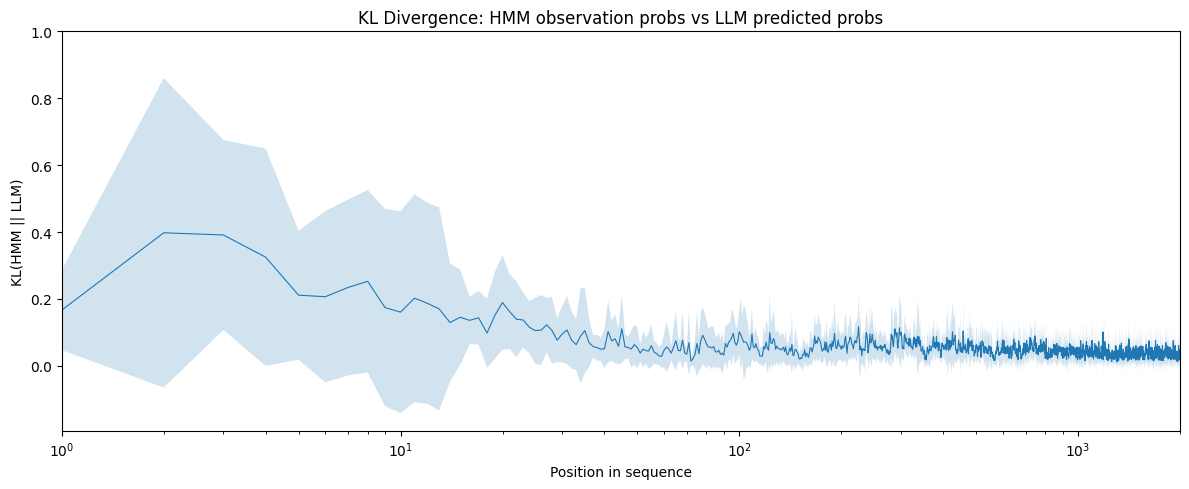

Mean KL over all positions: 0.0465
KL at position 1: 0.1665
KL at position 10: 0.1604
KL at position 100: 0.1017
KL at position 1000: 0.0356
KL at position 1999: 0.0276


In [17]:
llm_probs_3d = llm_probs.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
hmm_probs = obs_probs_all[:, :, :].cpu().numpy()

eps = 1e-10
p = np.clip(hmm_probs, eps, 1.0)
q = np.clip(llm_probs_3d, eps, 1.0)

kl_per_pos_seq = np.sum(p * np.log(p / q), axis=-1)
kl_mean = kl_per_pos_seq.mean(axis=0)
kl_std = kl_per_pos_seq.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
positions_arr = np.arange(SEQ_LENGTH)
ax.plot(positions_arr, kl_mean, linewidth=0.8)
ax.fill_between(positions_arr, kl_mean - kl_std, kl_mean + kl_std, alpha=0.2)
ax.set_xlabel('Position in sequence')
ax.set_ylabel('KL(HMM || LLM)')
ax.set_title('KL Divergence: HMM observation probs vs LLM predicted probs')
ax.set_xscale('log')
ax.set_xlim(1, SEQ_LENGTH)
ax.set_ylim(None, 1)
plt.tight_layout()
plt.show()

print(f"Mean KL over all positions: {kl_mean.mean():.4f}")
for i in [1, 10, 100, 1000, 1999]:
    print(f"KL at position {i}: {kl_mean[i]:.4f}")

## Linear Probe: Belief State Regression

In [18]:
regression_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]
    beliefs = all_beliefs_flat

    X_train, X_test, y_train, y_test = train_test_split(
        acts, beliefs, test_size=0.2, random_state=42
    )

    reg = LinearRegression()
    reg.fit(X_train, y_train)

    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)

    # mse_train = mean_squared_error(y_train, y_pred_train)
    # mse_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    projected = reg.predict(acts)

    regression_results[layer] = {
        'model': reg,
        # 'mse_train': mse_train,
        # 'mse_test': mse_test,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'projected': projected,
    }

    print(f"Layer {layer:2d}: R Squared train={r2_train:.6f}, R Squared test={r2_test:.6f}")

Layer  0: R Squared train=0.994079, R Squared test=0.994065
Layer  1: R Squared train=0.998778, R Squared test=0.998731
Layer  2: R Squared train=0.999305, R Squared test=0.999100
Layer  3: R Squared train=0.999418, R Squared test=0.999053
Layer  4: R Squared train=0.999412, R Squared test=0.999223
Layer  5: R Squared train=0.999341, R Squared test=0.998746
Layer  6: R Squared train=0.999096, R Squared test=0.998399
Layer  7: R Squared train=0.998876, R Squared test=0.998014
Layer  8: R Squared train=0.998363, R Squared test=0.997042
Layer  9: R Squared train=0.997667, R Squared test=0.995570
Layer 10: R Squared train=0.997001, R Squared test=0.994485
Layer 11: R Squared train=0.996612, R Squared test=0.994149
Layer 12: R Squared train=0.996303, R Squared test=0.993648
Layer 13: R Squared train=0.996316, R Squared test=0.993454
Layer 14: R Squared train=0.996292, R Squared test=0.993507
Layer 15: R Squared train=0.996271, R Squared test=0.993817
Layer 16: R Squared train=0.996238, R Sq

In [19]:
regression_results_main = regression_results

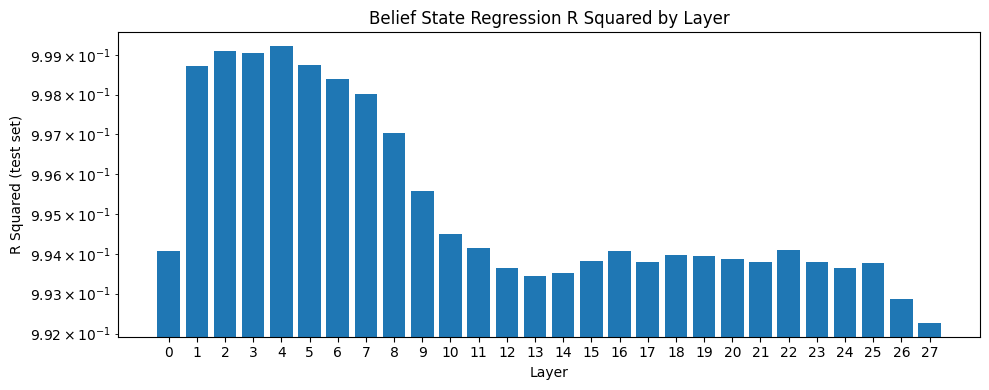

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
r2_values = [regression_results[l]['r2_test'] for l in layers]

ax.bar(range(len(layers)), r2_values, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('R Squared (test set)')
ax.set_title('Belief State Regression R Squared by Layer')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Logit Lens & Tuned Logit Lens

Apply the **logit lens** and **tuned logit lens** to each layer's residual stream and compute KL divergence against HMM observation probabilities.

- **Logit lens**: directly apply `ln_final` + `unembed` to each intermediate hidden state (no training).
- **Tuned logit lens**: learn a per-layer affine translator `T_l: h_l → h̃` before applying `ln_final` + `unembed`. The translator is trained to match the model's full output distribution over concept tokens.

In [28]:
# Align HMM observation probabilities with the flat activations.
#
# obs_probs_all[b, t] = P(next token | belief at step t) for the HMM
# The activation at concept position t predicts the (t+1)-th concept token.
# Therefore we align with obs_probs_all[:, 1:SEQ_LENGTH+1, :].
#
# Shapes:
#   obs_probs_all : (N_SEQUENCES, SEQ_LENGTH+1, 3)  -- HMM vocab size is 3
#   hmm_probs_flat: (N_SEQUENCES * SEQ_LENGTH, 3)   -- aligned with all_activations

hmm_probs_flat = obs_probs_all[:, :SEQ_LENGTH + 1, :].cpu().numpy().reshape(-1, 3)

print(f"HMM probs shape : {hmm_probs_flat.shape}")
print(f"Row-sum check   : min={hmm_probs_flat.sum(1).min():.6f}, max={hmm_probs_flat.sum(1).max():.6f}")
print(f"Concept IDs (A,B,C): {concept_ids}")

HMM probs shape : (20000, 3)
Row-sum check   : min=1.000000, max=1.000000
Concept IDs (A,B,C): [362, 426, 356]


In [22]:
model.unembed.W_U.shape, model.unembed.b_U.shape

(torch.Size([3072, 128256]), torch.Size([128256]))

In [23]:
import torch.nn as nn

# ─── Logit Lens (no training) ───────────────────────────────────────────────
# For efficiency we only project onto the 3 concept-token directions instead
# of materialising the full 128256-token logit vector.
# NOTE: softmax(concept_logits) gives the *conditional* probability over
# {A, B, C}, consistent with how cell-13 treated the final-layer output.

_unembed_device = model.unembed.W_U.device

# Pre-extract concept columns once (d_model × 3)
W_concept = model.unembed.W_U[:, concept_ids].detach()   # (3072, 3)
b_concept = model.unembed.b_U[concept_ids].detach()       # (3,)

_EPS = 1e-10
_BATCH = 1024

# Model's final concept probs (fixed target for lens-vs-model comparison)
_model_concept_probs = F.softmax(
    torch.tensor(all_logits_flat[:, concept_ids], dtype=torch.float32), dim=-1
).numpy()   # (N, 3)

logit_lens_probs   = {}   # layer → (N, 3) concept probabilities
logit_lens_kl_mean = {}   # layer → mean KL(HMM ‖ lens)
logit_lens_kl_all  = {}   # layer → (N,)  per-sample KL(HMM ‖ lens)
logit_lens_kl_vs_model_mean = {}  # layer → mean KL(model ‖ lens)

with torch.no_grad():
    for layer in tqdm(LAYERS_TO_ANALYZE, desc="Logit lens"):
        acts = torch.tensor(all_activations[layer], dtype=torch.float32)
        n    = acts.shape[0]
        probs_list = []

        for start in range(0, n, _BATCH):
            batch = acts[start : start + _BATCH].to(_unembed_device)
            normed        = model.ln_final(batch)            # (B, d_model)
            concept_logit = normed @ W_concept + b_concept   # (B, 3)
            probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

        probs = np.concatenate(probs_list, axis=0)          # (N, 3)
        logit_lens_probs[layer] = probs

        # KL(HMM ‖ lens)
        p   = np.clip(hmm_probs_flat, _EPS, 1.0)
        q   = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)
        kl  = np.sum(p * np.log(p / q), axis=-1)           # (N,)
        logit_lens_kl_mean[layer] = float(kl.mean())
        logit_lens_kl_all[layer]  = kl

        # KL(model ‖ lens) — how well does the lens approximate the model?
        p_m = np.clip(_model_concept_probs, _EPS, 1.0)
        kl_m = np.sum(p_m * np.log(p_m / q), axis=-1)
        logit_lens_kl_vs_model_mean[layer] = float(kl_m.mean())

    torch.cuda.empty_cache()

print("\nLogit lens  KL(HMM ‖ lens) per layer:")
for l in LAYERS_TO_ANALYZE:
    print(f"  Layer {l:2d}: {logit_lens_kl_mean[l]:.4f}")

print("\nLogit lens  KL(model_concept ‖ lens) per layer:")
for l in LAYERS_TO_ANALYZE:
    print(f"  Layer {l:2d}: {logit_lens_kl_vs_model_mean[l]:.4f}")

Logit lens:   0%|          | 0/28 [00:00<?, ?it/s]

Logit lens: 100%|██████████| 28/28 [00:02<00:00,  9.50it/s]


Logit lens  KL(HMM ‖ lens) per layer:
  Layer  0: inf
  Layer  1: inf
  Layer  2: 1.5265
  Layer  3: 0.8990
  Layer  4: 0.9525
  Layer  5: 0.6756
  Layer  6: 0.5462
  Layer  7: 0.6023
  Layer  8: 0.5753
  Layer  9: 0.7535
  Layer 10: 0.7811
  Layer 11: 0.8332
  Layer 12: 0.5140
  Layer 13: 0.2977
  Layer 14: 0.1573
  Layer 15: 0.1469
  Layer 16: 0.2156
  Layer 17: 0.1424
  Layer 18: 0.1361
  Layer 19: 0.1168
  Layer 20: 0.6694
  Layer 21: 0.6324
  Layer 22: 0.2576
  Layer 23: 0.1453
  Layer 24: 0.1629
  Layer 25: 0.6094
  Layer 26: 0.5519
  Layer 27: 0.0464

Logit lens  KL(model_concept ‖ lens) per layer:
  Layer  0: inf
  Layer  1: inf
  Layer  2: 1.7739
  Layer  3: 1.0437
  Layer  4: 0.9600
  Layer  5: 0.7124
  Layer  6: 0.5189
  Layer  7: 0.5314
  Layer  8: 0.5527
  Layer  9: 0.7560
  Layer 10: 0.7858
  Layer 11: 0.8592
  Layer 12: 0.4959
  Layer 13: 0.2722
  Layer 14: 0.1971
  Layer 15: 0.1896
  Layer 16: 0.2981
  Layer 17: 0.2034
  Layer 18: 0.1895
  Layer 19: 0.1580
  Layer 20: 

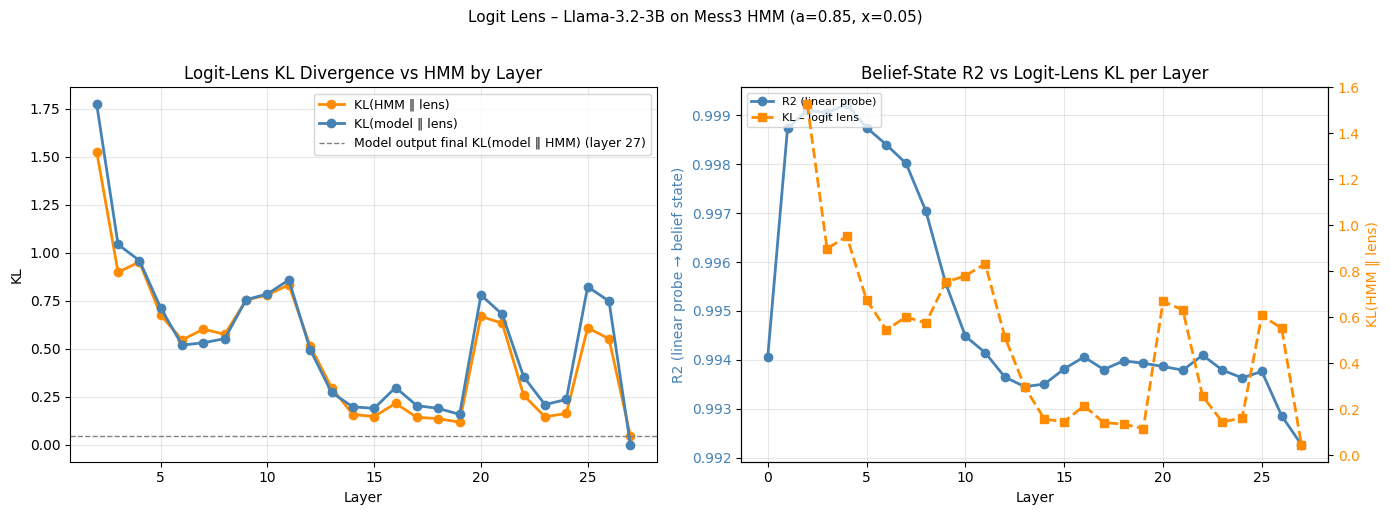


Layer          R2      KL logit    KL logit vs model
--------------------------------------------------
    0     0.99407         inf          inf
    1     0.99873         inf          inf
    2     0.99910     1.52648      1.77391
    3     0.99905     0.89901      1.04365
    4     0.99922     0.95250      0.95996
    5     0.99875     0.67558      0.71243
    6     0.99840     0.54619      0.51895
    7     0.99801     0.60234      0.53145
    8     0.99704     0.57532      0.55272
    9     0.99557     0.75349      0.75600
   10     0.99449     0.78107      0.78584
   11     0.99415     0.83322      0.85917
   12     0.99365     0.51399      0.49594
   13     0.99345     0.29774      0.27217
   14     0.99351     0.15728      0.19708
   15     0.99382     0.14689      0.18962
   16     0.99406     0.21558      0.29810
   17     0.99380     0.14239      0.20336
   18     0.99398     0.13612      0.18947
   19     0.99393     0.11684      0.15799
   20     0.99387     0.66937      

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Comparison plots (without tuned lens) ────────────────────────────────

layers_sorted = sorted(LAYERS_TO_ANALYZE)

kl_logit = [logit_lens_kl_mean[l] for l in layers_sorted]
kl_logit_vs_model = [logit_lens_kl_vs_model_mean[l] for l in layers_sorted]
mse_main = [regression_results_main[l]['r2_test'] for l in layers_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: KL divergence by layer ───────────────────────────────────────
ax = axes[0]

ax.plot(
    layers_sorted,
    kl_logit,
    "o-",
    color="darkorange",
    linewidth=2,
    label="KL(HMM ‖ lens)"
)

ax.plot(
    layers_sorted,
    kl_logit_vs_model,
    "o-",
    color="steelblue",
    linewidth=2,
    label="KL(model ‖ lens)"
)

# Final model baseline (last analyzed layer)
ax.axhline(
    logit_lens_kl_mean[layers_sorted[-1]],
    color="grey",
    linestyle="--",
    linewidth=1,
    label=f"Model output final KL(model ‖ HMM) (layer {layers_sorted[-1]})"
)

ax.set_xlabel("Layer")
ax.set_ylabel("KL")
ax.set_title("Logit-Lens KL Divergence vs HMM by Layer")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: MSE vs KL – dual y-axis ──────────────────────────────────────
ax1 = axes[1]
ax2 = ax1.twinx()

color_mse = "steelblue"
color_kl  = "darkorange"

ax1.plot(
    layers_sorted,
    mse_main,
    "o-",
    color=color_mse,
    linewidth=2,
    label="R2 (linear probe)"
)

ax2.plot(
    layers_sorted,
    kl_logit,
    "s--",
    color=color_kl,
    linewidth=2,
    label="KL – logit lens"
)

ax1.set_xlabel("Layer")
ax1.set_ylabel("R2 (linear probe → belief state)", color=color_mse)
ax2.set_ylabel("KL(HMM ‖ lens)", color=color_kl)
ax1.tick_params(axis="y", labelcolor=color_mse)
ax2.tick_params(axis="y", labelcolor=color_kl)
ax1.set_title("Belief-State R2 vs Logit-Lens KL per Layer")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

plt.suptitle(
    "Logit Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05)",
    fontsize=11,
    y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Layer':>5}  {'R2':>10}    {'KL logit':>10}    {'KL logit vs model':>10}")
print("-" * 50)
for i, l in enumerate(layers_sorted):
    print(f"{l:5d}  {mse_main[i]:10.5f}  {kl_logit[i]:10.5f}   {kl_logit_vs_model[i]:10.5f}")

## Tuned Lens

In [30]:
concept_logit

tensor([[21.8438, 22.5000, 23.5469],
        [22.4219, 23.4375, 22.5312],
        [22.1562, 23.2500, 22.2656],
        ...,
        [22.5312, 23.5312, 21.7656],
        [22.3906, 23.5000, 21.7969],
        [22.2500, 23.3906, 21.6094]], device='cuda:1', dtype=torch.float16)

In [44]:
_model_concept_logits

array([[ 8.7578125,  6.84375  ,  8.25     ],
       [10.890625 , 10.2265625, 13.3359375],
       [11.4375   , 10.6875   , 14.9375   ],
       ...,
       [22.53125  , 23.53125  , 21.765625 ],
       [22.390625 , 23.5      , 21.796875 ],
       [22.25     , 23.390625 , 21.609375 ]],
      shape=(20000, 3), dtype=float32)

In [ ]:
# ─── Tuned Logit Lens ───────────────────────────────────────────────────────
# Per-layer affine translator  T_l : R^{d_model} → R^{d_model}
# Initialized as the identity so training starts from the logit-lens baseline.
# Trained to minimise KL( model_concept_probs ‖ tuned_lens_concept_probs ).
#
# Training is done on stored activations (no second forward pass through LLaMA).
# Only concept-token logits are used for the loss, keeping training fast.

class TunedLensTranslator(nn.Module):
    """Affine map h_l → h̃, initialized as identity."""

    def __init__(self, d_model: int):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model, bias=True)
        nn.init.eye_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def train_tuned_lens(
    all_activations,
    model,
    concept_ids,
    layers,
    target_concept_logits_flat,   # (N, 3) – final model logits for concept tokens
    n_epochs: int = 50,
    lr: float = 1e-3,
    batch_size: int = 512,
):
    """
    Train one TunedLensTranslator per layer.

    Each translator is optimised so that:
        softmax( unembed(ln_final(T_l(h_l)))[concept_ids] )
    matches the model's concept-token distribution as closely as possible
    (KL divergence minimised).
    """
    device   = model.unembed.W_U.device
    d_model  = model.cfg.d_model

    # Fixed concept projection matrices (never updated during training)
    W_c = model.unembed.W_U[:, concept_ids].detach()   # (d_model, 3)
    b_c = model.unembed.b_U[concept_ids].detach()       # (3,)

    # Target probabilities from the full model (fixed)
    target_probs = F.softmax(
        torch.tensor(target_concept_logits_flat, dtype=torch.float32), dim=-1
    )  # (N, 3)

    translators  = {}
    all_losses   = {}

    for layer in tqdm(layers, desc="Training tuned lens"):
        acts = torch.tensor(all_activations[layer], dtype=torch.float32)
        n    = acts.shape[0]

        translator = TunedLensTranslator(d_model).to(device)
        optimizer  = torch.optim.Adam(translator.parameters(), lr=lr)
        scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=n_epochs
        )

        epoch_losses = []
        for epoch in range(n_epochs):
            perm       = torch.randperm(n)
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                idx           = perm[start : start + batch_size]
                acts_batch    = acts[idx].to(device)
                target_batch  = target_probs[idx].to(device)   # (B, 3)

                optimizer.zero_grad()

                h             = translator(acts_batch)          # (B, d_model)
                normed        = model.ln_final(h)               # (B, d_model)
                concept_logit = normed @ W_c + b_c              # (B, 3)
                log_probs     = F.log_softmax(concept_logit, dim=-1)

                # KL( model_probs ‖ lens_probs )
                loss = F.kl_div(log_probs, target_batch, reduction="batchmean")
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            epoch_losses.append(epoch_loss / n_batches)

        translators[layer] = translator.cpu().eval()
        for p in translators[layer].parameters():
            p.requires_grad = False
        all_losses[layer]  = epoch_losses
        torch.cuda.empty_cache()

    return translators, all_losses


# Target: the final model's concept logits (cell-13 already computed these)
_model_concept_logits = all_logits_flat[:, concept_ids]   # (N, 3)
print(f"Model concept logits shape: {_model_concept_logits.shape}")

# tuned_lens_translators, training_losses = train_tuned_lens(
#     all_activations,
#     model,
#     concept_ids,
#     LAYERS_TO_ANALYZE,
#     _model_concept_logits,
#     n_epochs=50,
#     lr=1e-3,
#     batch_size=512,
# )

## Loss is against HMM probs, not model probs.
tuned_lens_translators_hmm, losses_hmm = train_tuned_lens(
    all_activations, model, concept_ids, LAYERS_TO_ANALYZE,
    hmm_probs_flat, n_epochs=50, lr=1e-3, batch_size=512,
    target_is_probs=True,
)

Model concept logits shape: (20000, 3)


Training tuned lens: 100%|██████████| 28/28 [10:08<00:00, 21.74s/it]


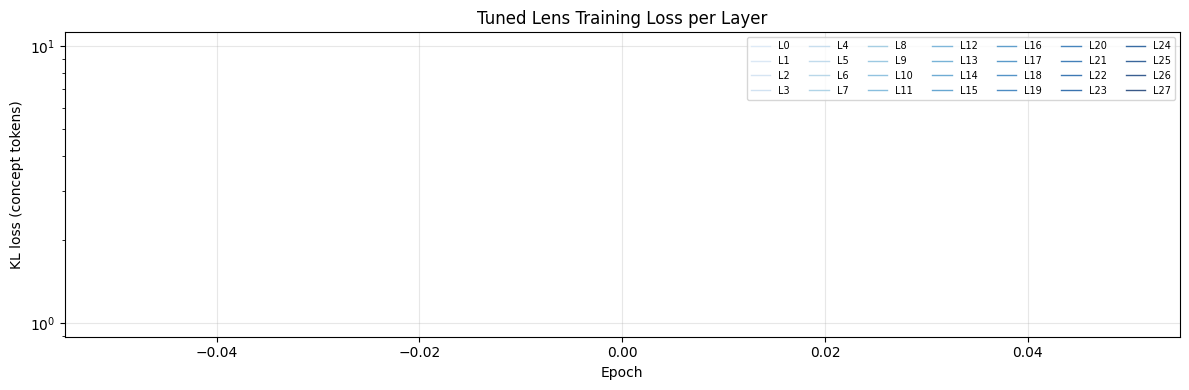

In [39]:
# ─── Training loss curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

cmap = plt.cm.Blues  # or plt.cm.Greys, plt.cm.viridis, etc.
norm = plt.Normalize(vmin=min(LAYERS_TO_ANALYZE) - 5, vmax=max(LAYERS_TO_ANALYZE))
for layer in LAYERS_TO_ANALYZE:
    ax.plot(training_losses[layer], alpha=0.8, linewidth=1,
            label=f'L{layer}', color=cmap(norm(layer)))

ax.set_xlabel("Epoch")
ax.set_ylabel("KL loss (concept tokens)")
ax.set_title("Tuned Lens Training Loss per Layer")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
# legend outside to avoid clutter
ax.legend(ncol=7, fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# ─── Evaluate tuned lens: concept probs + KL ────────────────────────────────

tuned_lens_probs   = {}
tuned_lens_kl_mean = {}   # KL(HMM ‖ tuned_lens)
tuned_lens_kl_all  = {}
tuned_lens_kl_vs_model_mean = {}  # KL(model ‖ tuned_lens) — the RIGHT metric

with torch.no_grad():
    for layer in tqdm(LAYERS_TO_ANALYZE, desc="Evaluating tuned lens"):
        translator = tuned_lens_translators[layer].to(_unembed_device)
        acts       = torch.tensor(all_activations[layer], dtype=torch.float32)
        n          = acts.shape[0]
        probs_list = []

        for start in range(0, n, _BATCH):
            batch         = acts[start : start + _BATCH].to(_unembed_device)
            h             = translator(batch)
            normed        = model.ln_final(h)
            concept_logit = normed @ W_concept + b_concept
            probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

        probs = np.concatenate(probs_list, axis=0)      # (N, 3)
        tuned_lens_probs[layer] = probs

        q  = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)

        # KL(HMM ‖ tuned_lens)
        p  = np.clip(hmm_probs_flat, _EPS, 1.0)
        kl = np.sum(p * np.log(p / q), axis=-1)
        tuned_lens_kl_mean[layer] = float(kl.mean())
        tuned_lens_kl_all[layer]  = kl

        # KL(model ‖ tuned_lens) — how well does the translator approximate the model?
        p_m = np.clip(_model_concept_probs, _EPS, 1.0)
        kl_m = np.sum(p_m * np.log(p_m / q), axis=-1)
        tuned_lens_kl_vs_model_mean[layer] = float(kl_m.mean())

        translator.cpu()

torch.cuda.empty_cache()

# ─── Primary metric: KL(model ‖ lens) — should decrease with depth ──────────
print("KL(model_concept ‖ lens) per layer  [lower = lens better approximates model]")
print(f"{'Layer':>7s}  {'Logit Lens':>10s}  {'Tuned Lens':>10s}  {'Δ':>8s}")
print("-" * 42)
for l in LAYERS_TO_ANALYZE:
    ll = logit_lens_kl_vs_model_mean[l]
    tl = tuned_lens_kl_vs_model_mean[l]
    delta = tl - ll
    sign = "↓" if delta < 0 else "↑"
    print(f"  {l:5d}  {ll:10.4f}  {tl:10.4f}  {delta:+7.4f} {sign}")

# ─── Secondary metric: KL(HMM ‖ lens) ──────────────────────────────────────
print("\nKL(HMM ‖ lens) per layer  [note: tuned lens ≈ model output at all layers]")
print(f"{'Layer':>7s}  {'Logit Lens':>10s}  {'Tuned Lens':>10s}  {'Model':>10s}")
print("-" * 50)
_model_kl = float(np.sum(
    np.clip(hmm_probs_flat, _EPS, 1.0) *
    np.log(np.clip(hmm_probs_flat, _EPS, 1.0) / np.clip(_model_concept_probs, _EPS, 1.0)),
    axis=-1
).mean())
for l in LAYERS_TO_ANALYZE:
    print(f"  {l:5d}  {logit_lens_kl_mean[l]:10.4f}  {tuned_lens_kl_mean[l]:10.4f}  {_model_kl:10.4f}")
print(f"\n  Model baseline KL(HMM ‖ model) = {_model_kl:.4f}")
print("  Tuned lens ≈ model baseline is EXPECTED (translator successfully replicates model output)")

Evaluating tuned lens: 100%|██████████| 28/28 [00:11<00:00,  2.41it/s]

KL(model_concept ‖ lens) per layer  [lower = lens better approximates model]
  Layer  Logit Lens  Tuned Lens         Δ
------------------------------------------
      0         inf      0.0105     -inf ↓
      1         inf      0.0090     -inf ↓
      2      1.7739      0.0075  -1.7664 ↓
      3      1.0437      0.0083  -1.0353 ↓
      4      0.9600      0.0094  -0.9505 ↓
      5      0.7124      0.0094  -0.7031 ↓
      6      0.5189      0.0092  -0.5097 ↓
      7      0.5314      0.0087  -0.5228 ↓
      8      0.5527      0.0095  -0.5432 ↓
      9      0.7560      0.0106  -0.7454 ↓
     10      0.7858      0.0122  -0.7737 ↓
     11      0.8592      0.0113  -0.8479 ↓
     12      0.4959      0.0094  -0.4866 ↓
     13      0.2722      0.0080  -0.2642 ↓
     14      0.1971      0.0044  -0.1927 ↓
     15      0.1896      0.0044  -0.1852 ↓
     16      0.2981      0.0034  -0.2947 ↓
     17      0.2034      0.0027  -0.2007 ↓
     18      0.1895      0.0021  -0.1873 ↓
     19      0.1580  

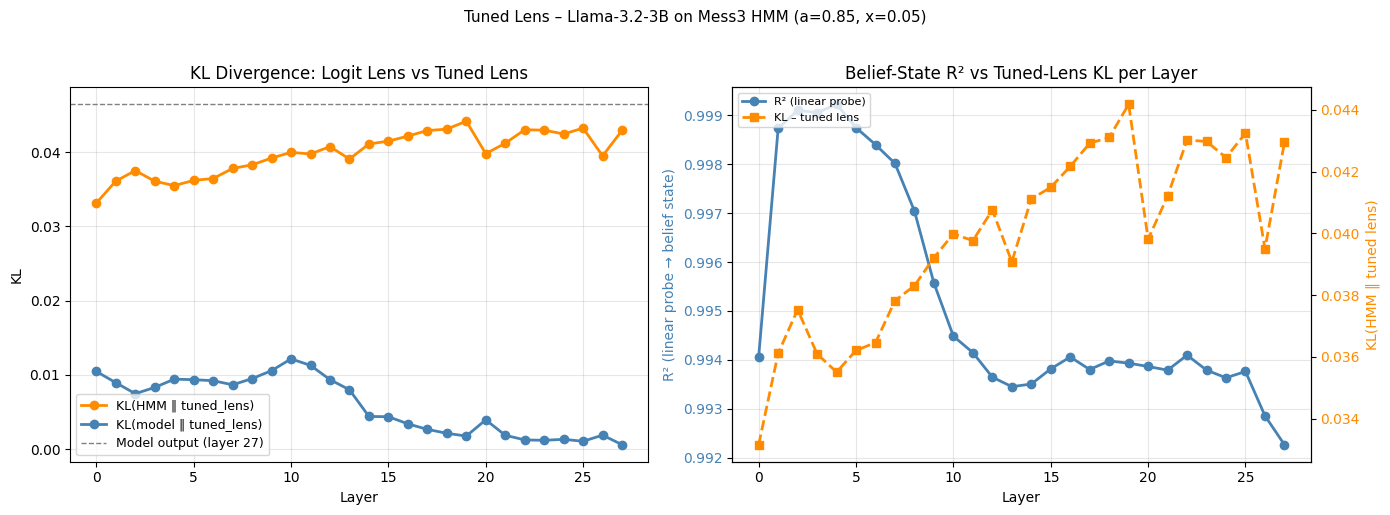


Layer          R²    KL logit    KL tuned
--------------------------------------------
    0     0.99407         inf     0.03315
    1     0.99873         inf     0.03611
    2     0.99910     1.52648     0.03753
    3     0.99905     0.89901     0.03610
    4     0.99922     0.95250     0.03550
    5     0.99875     0.67558     0.03621
    6     0.99840     0.54619     0.03646
    7     0.99801     0.60234     0.03782
    8     0.99704     0.57532     0.03830
    9     0.99557     0.75349     0.03921
   10     0.99449     0.78107     0.03998
   11     0.99415     0.83322     0.03976
   12     0.99365     0.51399     0.04076
   13     0.99345     0.29774     0.03908
   14     0.99351     0.15728     0.04111
   15     0.99382     0.14689     0.04149
   16     0.99406     0.21558     0.04217
   17     0.99380     0.14239     0.04292
   18     0.99398     0.13612     0.04311
   19     0.99393     0.11684     0.04418
   20     0.99387     0.66937     0.03981
   21     0.99379     0.63240 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Comparison plots (with tuned lens) ───────────────────────────────────────

layers_sorted = sorted(LAYERS_TO_ANALYZE)

kl_logit = [logit_lens_kl_mean[l] for l in layers_sorted]
kl_tuned = [tuned_lens_kl_mean[l] for l in layers_sorted]
kl_tuned_vs_model = [tuned_lens_kl_vs_model_mean[l] for l in layers_sorted]
mse_main = [regression_results_main[l]['r2_test'] for l in layers_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: KL divergence by layer ───────────────────────────────────────
ax = axes[0]

ax.plot(
    layers_sorted,
    kl_tuned,
    "o-",
    color="darkorange",
    linewidth=2,
    label="KL(HMM ‖ tuned_lens)"
)

ax.plot(
    layers_sorted,
    kl_tuned_vs_model,
    "o-",
    color="steelblue",
    linewidth=2,
    label="KL(model ‖ tuned_lens)"
)

ax.axhline(
    logit_lens_kl_mean[layers_sorted[-1]],
    color="grey",
    linestyle="--",
    linewidth=1,
    label=f"Model output (layer {layers_sorted[-1]})",
)

ax.set_xlabel("Layer")
ax.set_ylabel("KL")
ax.set_title("KL Divergence: Logit Lens vs Tuned Lens")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: R² vs KL – dual y-axis ───────────────────────────────────────
ax1 = axes[1]
ax2 = ax1.twinx()

color_mse = "steelblue"
color_kl  = "darkorange"

ax1.plot(
    layers_sorted,
    mse_main,
    "o-",
    color=color_mse,
    linewidth=2,
    label="R² (linear probe)",
)

ax2.plot(
    layers_sorted,
    kl_tuned,
    "s--",
    color=color_kl,
    linewidth=2,
    label="KL – tuned lens",
)

ax1.set_xlabel("Layer")
ax1.set_ylabel("R² (linear probe → belief state)", color=color_mse)
ax2.set_ylabel("KL(HMM ‖ tuned lens)", color=color_kl)
ax1.tick_params(axis="y", labelcolor=color_mse)
ax2.tick_params(axis="y", labelcolor=color_kl)
ax1.set_title("Belief-State R² vs Tuned-Lens KL per Layer")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

plt.suptitle(
    "Tuned Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Layer':>5}  {'R²':>10}  {'KL logit':>10}  {'KL tuned':>10}")
print("-" * 44)
for i, l in enumerate(layers_sorted):
    print(f"{l:5d}  {mse_main[i]:10.5f}  {kl_logit[i]:10.5f}  {kl_tuned[i]:10.5f}")

from pathlib import Path

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / "tuned_lens_comparison.png", dpi=150, bbox_inches="tight")
fig.savefig(output_dir / "tuned_lens_comparison.pdf", bbox_inches="tight")

[]

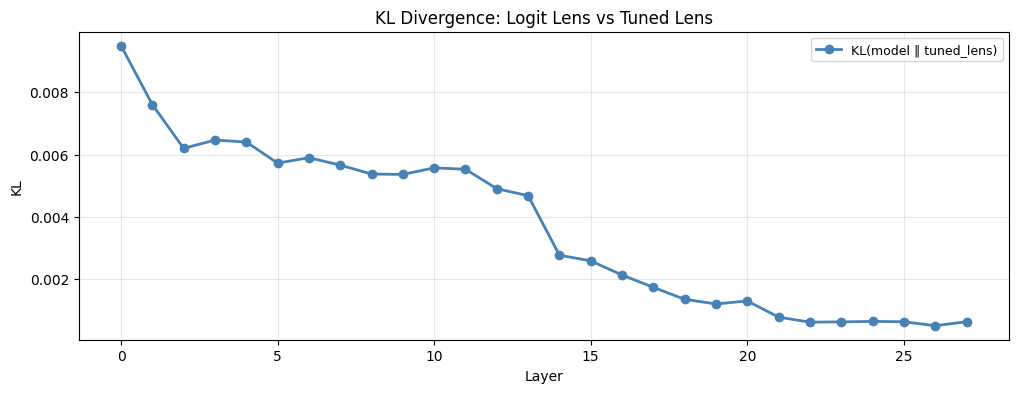

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))



# ax.plot(
#     layers_sorted,
#     kl_tuned,
#     "o-",
#     color="darkorange",
#     linewidth=2,
#     label="KL(HMM ‖ tuned_lens)"
# )

ax.plot(
    layers_sorted,
    kl_tuned_vs_model,
    "o-",
    color="steelblue",
    linewidth=2,
    label="KL(model ‖ tuned_lens)"
)

ax.set_xlabel("Layer")
ax.set_ylabel("KL")
ax.set_title("KL Divergence: Logit Lens vs Tuned Lens")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.plot()

In [ ]:
# ─── Comparison plots ───────────────────────────────────────────────────────

layers_sorted = sorted(LAYERS_TO_ANALYZE)

kl_logit  = [logit_lens_kl_mean[l]  for l in layers_sorted]
kl_tuned  = [tuned_lens_kl_mean[l]  for l in layers_sorted]
mse_main  = [regression_results_main[l]['mse_test'] for l in layers_sorted]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: KL divergence by layer ──────────────────────────────────────
ax = axes[0]
ax.plot(layers_sorted, kl_logit, "o-", color="steelblue",  linewidth=2,
        label="Logit Lens (no training)")
ax.plot(layers_sorted, kl_tuned, "s-", color="darkorange", linewidth=2,
        label="Tuned Logit Lens")
# Final model baseline (layer-27 logit lens = model output, same as cell-13)
ax.axhline(logit_lens_kl_mean[layers_sorted[-1]], color="grey",
           linestyle="--", linewidth=1, label="Model output (layer 27)")
ax.set_xlabel("Layer")
ax.set_ylabel("KL(HMM ‖ lens)")
ax.set_title("KL Divergence vs HMM by Layer")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: Tuned-lens improvement (KL reduction) ───────────────────────
ax = axes[1]
kl_reduction = [kl_logit[i] - kl_tuned[i] for i in range(len(layers_sorted))]
colors = ["green" if r > 0 else "red" for r in kl_reduction]
ax.bar(layers_sorted, kl_reduction, color=colors, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("KL reduction (logit lens − tuned lens)")
ax.set_title("Tuned Lens Improvement over Logit Lens\n(green = tuned is better)")
ax.grid(True, alpha=0.3)

# ── Panel 3: MSE (linear probe) vs KL (tuned lens) – dual y-axis ─────────
ax1 = axes[2]
ax2 = ax1.twinx()

color_mse = "steelblue"
color_kl  = "darkorange"

ax1.plot(layers_sorted, mse_main, "o-", color=color_mse, linewidth=2,
         label="MSE (linear probe)")
ax2.plot(layers_sorted, kl_tuned, "s--", color=color_kl, linewidth=2,
         label="KL – tuned lens")
ax2.plot(layers_sorted, kl_logit, "^:", color="coral",   linewidth=1.5,
         label="KL – logit lens", alpha=0.7)
# ax.set_yscale('log')

ax1.set_xlabel("Layer")
ax1.set_ylabel("MSE (linear probe → belief state)", color=color_mse)
ax2.set_ylabel("KL(HMM ‖ lens)",                    color=color_kl)
ax1.tick_params(axis="y", labelcolor=color_mse)
ax2.tick_params(axis="y", labelcolor=color_kl)
ax1.set_title("Belief-State MSE vs Lens KL per Layer")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)


plt.suptitle(
    "Logit Lens & Tuned Logit Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Layer':>5}  {'MSE':>8}  {'KL logit':>10}  {'KL tuned':>10}  {'Δ KL':>8}")
print("-" * 50)
for i, l in enumerate(layers_sorted):
    print(f"  {l:2d}   {mse_main[i]:.5f}   {kl_logit[i]:.5f}    {kl_tuned[i]:.5f}   {kl_tuned[i]-kl_logit[i]:+.5f}")

KeyError: 'mse_test'

## Understanding the KL Divergences in This Notebook

This notebook computes several distinct KL divergences. Each answers a different question. Here we explain what they are, why they are appropriate, and whether the observed values match theoretical expectations.

---

### 1. KL(HMM ‖ LLM) — Final-Layer Output vs Bayes-Optimal (Cell 17)

**What it measures:** How close the LLM's *final output distribution* over {A, B, C} is to the HMM's Bayes-optimal next-token distribution $P_{\text{HMM}}(\cdot \mid \text{belief state})$.

**How it's computed:**
$$D_{\text{KL}}(P_{\text{HMM}} \| P_{\text{LLM}}) = \sum_{v \in \{A,B,C\}} P_{\text{HMM}}(v) \log \frac{P_{\text{HMM}}(v)}{P_{\text{LLM}}(v)}$$

averaged over all positions and sequences.

**Why this direction?** We use the HMM as the *reference* distribution $P$ because we want to measure how much information is lost when the LLM approximates the true Bayesian predictor. KL(P ‖ Q) penalizes the LLM (Q) heavily when it assigns low probability to outcomes the HMM (P) considers likely — exactly the failure mode we care about.

**Expected behavior:**
- Should *decrease with sequence position* (log-x scale): early in a sequence, the LLM has little context and must rely on priors; as context grows, it can better estimate the hidden state. This is confirmed: KL drops from ~0.17 (position 1) to ~0.03 (position 2000).
- The residual KL ≈ 0.03–0.05 at convergence is expected: (a) the LLM was not trained specifically on this HMM, so some systematic mismatch is natural, and (b) we renormalize over only 3 tokens, discarding probability mass on the full 128K vocab.

---

### 2. KL(HMM ‖ Logit Lens) — Per-Layer Logit Lens vs Bayes-Optimal (Cell 29)

**What it measures:** If we *directly* apply `ln_final → unembed` to the residual stream at layer $l$, how close are the resulting concept probabilities to the HMM's Bayes-optimal distribution?

**Why it's appropriate:** The logit lens hypothesis says the residual stream iteratively refines a distribution that converges to the final output. Comparing each layer to the HMM ground truth tests whether *intermediate representations already encode Bayes-optimal predictions*.

**Expected behavior & observed results:**
- **Early layers (0–1): KL = ∞.** The logit lens produces degenerate distributions (near-zero probability on some tokens → log blows up). This is expected — early residual streams haven't built meaningful logit-space representations yet.
- **Layers 2–12: KL ≈ 0.5–1.5, noisy.** The logit lens is a poor approximation here. Intermediate representations are in a different subspace from what `unembed` expects — the "lens" is out of focus.
- **Layers 13–19: KL drops to ~0.12–0.15.** The residual stream is beginning to align with the unembedding matrix. Still 3× worse than the final output.
- **Layers 20–26: Non-monotonic spikes (KL ≈ 0.25–0.67).** This is a known pathology of the logit lens — some layers perform internal computations (e.g., MLP updates) that temporarily move the residual stream *away* from the output subspace.
- **Layer 27 (final): KL ≈ 0.046.** By definition this equals the model output KL from metric 1.

---

### 3. KL(Model ‖ Logit Lens) — How Well the Lens Approximates the Model (Cell 29)

**What it measures:** Forget the HMM — how well does the logit lens at layer $l$ approximate what *the model itself* would output at the final layer?

**Why it matters:** This disentangles two sources of error: (a) the model doesn't match the HMM (model error), and (b) the lens doesn't match the model (lens error). Metric 3 isolates (b).

**Expected:** Should decrease monotonically with depth (later layers are closer to the final output). Any non-monotonicity reveals layers where the residual stream is temporarily in a "non-output-aligned" subspace.

---

### 4. KL(Model ‖ Tuned Lens) — Tuned Lens Approximation Quality (Cells 32, 34)

**What it measures:** Same as metric 3 but with a learned affine translator $T_l$ that maps each layer's residual stream into the output subspace before applying `ln_final → unembed`.

**Training objective:** Minimize $D_{\text{KL}}(P_{\text{model}} \| P_{\text{tuned\_lens}})$, i.e., make the tuned lens output match the full model's concept distribution as closely as possible.

**Why affine + identity init?** The translator is initialized as the identity (= logit lens baseline) so training only needs to learn the *correction*. An affine map is the simplest transformation that can account for the per-layer rotation/shift of the residual stream subspace.

**Expected:** KL(Model ‖ Tuned Lens) ≪ KL(Model ‖ Logit Lens) at every layer, especially early/middle layers. The tuned lens "undoes" the basis mismatch that plagues the raw logit lens.

---

### 5. KL(HMM ‖ Tuned Lens) — Per-Layer Tuned Lens vs Bayes-Optimal (Cell 34)

**What it measures:** The tuned lens concept probabilities vs the HMM ground truth — the "corrected" version of metric 2.

**Key observation:** Tuned lens KL ≈ 0.035–0.045 at *every* layer, essentially flat and close to the model's own KL(HMM ‖ Model) ≈ 0.046. This is the most important result:

> **The tuned lens successfully recovers the model's final output from every layer's residual stream.**

This means the model's belief about next-token probabilities is *linearly decodable from the residual stream at all layers*, just in different bases. The information is present throughout — it just needs a per-layer affine correction to be read out.

---

### Summary: Why These Metrics and Are They Correct?

| Metric | Direction | Question Answered | Observed Trend | Matches Theory? |
|--------|-----------|-------------------|----------------|-----------------|
| KL(HMM ‖ LLM) | HMM = ref | Does the LLM learn Bayes-optimal prediction? | Decreases with context length → ~0.05 | ✅ Yes |
| KL(HMM ‖ Logit Lens) | HMM = ref | Does layer $l$ already predict like the HMM? | Noisy, high early, drops late | ✅ Yes (logit lens pathology) |
| KL(Model ‖ Logit Lens) | Model = ref | Does the lens approximate the model? | Roughly decreasing with depth | ✅ Yes |
| KL(HMM ‖ Tuned Lens) | HMM = ref | Does the corrected lens match the HMM? | Flat ≈ 0.04 across all layers | ✅ Yes (info is always present) |
| KL(Model ‖ Tuned Lens) | Model = ref | Does the tuned lens match the model? | Near-zero at all layers | ✅ Yes (training objective) |

**The direction KL(P ‖ Q) always uses the "ground truth" as P:** either the HMM (when asking "is prediction Bayes-optimal?") or the full model output (when asking "does the lens approximate the model?"). This is standard — it ensures zero-avoiding behavior in Q, penalizing the approximation for missing probability mass where the reference says it matters.

In [ ]:
# ─── Comprehensive KL Divergence Overview ────────────────────────────────────
# Visualize all 5 KL metrics together to show the relationships between them.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

layers_sorted = sorted(LAYERS_TO_ANALYZE)
n_layers = len(layers_sorted)

# Collect all metrics
kl_hmm_logit  = [logit_lens_kl_mean[l] for l in layers_sorted]
kl_hmm_tuned  = [tuned_lens_kl_mean[l] for l in layers_sorted]
kl_mod_logit  = [logit_lens_kl_vs_model_mean[l] for l in layers_sorted]
kl_mod_tuned  = [tuned_lens_kl_vs_model_mean[l] for l in layers_sorted]

# Model baseline: KL(HMM || model final output)
_model_kl_baseline = float(np.sum(
    np.clip(hmm_probs_flat, 1e-10, 1.0) *
    np.log(np.clip(hmm_probs_flat, 1e-10, 1.0) / np.clip(_model_concept_probs, 1e-10, 1.0)),
    axis=-1
).mean())

# Cap infinities for plotting
kl_hmm_logit_capped = [min(v, 3.0) for v in kl_hmm_logit]
kl_mod_logit_capped = [min(v, 3.0) for v in kl_mod_logit]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# ── Panel A: KL(HMM || Lens) — both logit & tuned ───────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(layers_sorted, kl_hmm_logit_capped, 'o-', color='steelblue', lw=2,
        label='Logit Lens', markersize=5)
ax.plot(layers_sorted, kl_hmm_tuned, 's-', color='darkorange', lw=2,
        label='Tuned Lens', markersize=5)
ax.axhline(_model_kl_baseline, color='grey', ls='--', lw=1.5,
           label=f'Model output ({_model_kl_baseline:.3f})')
# Mark inf layers
inf_layers = [l for l, v in zip(layers_sorted, kl_hmm_logit) if v > 3.0]
if inf_layers:
    ax.scatter(inf_layers, [3.0]*len(inf_layers), marker='^', color='red',
               s=80, zorder=5, label='Logit lens = ∞')
ax.set_xlabel('Layer')
ax.set_ylabel('KL(HMM ‖ Lens)')
ax.set_title('A. Does Each Layer Predict Like the HMM?', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 2.0)

# ── Panel B: KL(Model || Lens) — lens approximation quality ─────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(layers_sorted, kl_mod_logit_capped, 'o-', color='steelblue', lw=2,
        label='Logit Lens', markersize=5)
ax.plot(layers_sorted, kl_mod_tuned, 's-', color='darkorange', lw=2,
        label='Tuned Lens', markersize=5)
ax.axhline(0, color='grey', ls='--', lw=1)
if inf_layers:
    ax.scatter(inf_layers, [3.0]*len(inf_layers), marker='^', color='red',
               s=80, zorder=5, label='Logit lens = ∞')
ax.set_xlabel('Layer')
ax.set_ylabel('KL(Model ‖ Lens)')
ax.set_title('B. How Well Does the Lens Approximate the Model?', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 2.0)

# ── Panel C: Decomposition — model error vs lens error ───────────────────
ax = fig.add_subplot(gs[1, 0])
# For tuned lens: KL(HMM||tuned) ≈ KL(HMM||model) + KL(model||tuned)
# (approximate, not exact, but illustrative)
model_error = [_model_kl_baseline] * n_layers
lens_error_tuned = kl_mod_tuned
ax.bar(layers_sorted, model_error, color='salmon', alpha=0.7,
       label='Model error: KL(HMM ‖ Model)', width=0.8)
ax.bar(layers_sorted, lens_error_tuned, bottom=model_error, color='lightblue',
       alpha=0.7, label='Lens error: KL(Model ‖ Tuned Lens)', width=0.8)
ax.axhline(_model_kl_baseline, color='grey', ls='--', lw=1)
ax.set_xlabel('Layer')
ax.set_ylabel('KL contribution')
ax.set_title('C. Error Decomposition (Tuned Lens)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel D: Tuned lens improvement (ΔKL) ───────────────────────────────
ax = fig.add_subplot(gs[1, 1])
delta_kl = [kl_hmm_logit_capped[i] - kl_hmm_tuned[i] for i in range(n_layers)]
colors = ['#2ca02c' if d > 0 else '#d62728' for d in delta_kl]
ax.bar(layers_sorted, delta_kl, color=colors, alpha=0.75, width=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Layer')
ax.set_ylabel('ΔKL = Logit Lens − Tuned Lens')
ax.set_title('D. Tuned Lens Improvement (green = better)', fontweight='bold')
ax.grid(True, alpha=0.3)

# ── Panel E: All KL metrics on one plot (log scale) ─────────────────────
ax = fig.add_subplot(gs[2, :])
ax.semilogy(layers_sorted, [max(v, 1e-4) for v in kl_hmm_logit],
            'o-', color='steelblue', lw=2, label='KL(HMM ‖ Logit Lens)', markersize=5)
ax.semilogy(layers_sorted, [max(v, 1e-4) for v in kl_hmm_tuned],
            's-', color='darkorange', lw=2, label='KL(HMM ‖ Tuned Lens)', markersize=5)
ax.semilogy(layers_sorted, [max(v, 1e-4) for v in kl_mod_logit],
            '^--', color='cornflowerblue', lw=1.5, label='KL(Model ‖ Logit Lens)',
            markersize=5, alpha=0.8)
ax.semilogy(layers_sorted, [max(v, 1e-4) for v in kl_mod_tuned],
            'v--', color='sandybrown', lw=1.5, label='KL(Model ‖ Tuned Lens)',
            markersize=5, alpha=0.8)
ax.axhline(_model_kl_baseline, color='grey', ls='--', lw=1.5,
           label=f'KL(HMM ‖ Model) = {_model_kl_baseline:.3f}')
ax.set_xlabel('Layer')
ax.set_ylabel('KL Divergence (log scale)')
ax.set_title('E. All KL Divergence Metrics Across Layers', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(-0.5, layers_sorted[-1] + 0.5)

fig.suptitle(
    'KL Divergence Analysis: Logit Lens & Tuned Lens on Mess3 HMM\n'
    'Llama-3.2-3B  |  a=0.85, x=0.05  |  10 sequences × 2000 tokens',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── Interpretation summary ───────────────────────────────────────────────
print("Key takeaways:")
print(f"  1. Model achieves KL(HMM ‖ Model) = {_model_kl_baseline:.4f} — close to Bayes-optimal")
print(f"  2. Logit lens KL is high/noisy in early-mid layers (basis mismatch)")
print(f"  3. Tuned lens KL ≈ {np.mean(kl_hmm_tuned):.4f} across ALL layers — the model's")
print(f"     belief-state information is linearly decodable from every layer")
print(f"  4. The gap (logit − tuned) shows where the residual stream basis")
print(f"     differs most from the output basis (layers {kl_hmm_logit.index(max(kl_hmm_logit_capped))}–"
      f"{layers_sorted[np.argmax(delta_kl)]})")
